# Paper's Pipeline

In [2]:
import os
import pickle
import warnings

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.stats import pearsonr, beta as _beta_dist

from leaspy.io.data import Data
from leaspy.models import JointModel
from leaspy.datasets import load_dataset

warnings.filterwarnings("ignore", category=UserWarning)

## Reference model (source of true $\theta$)

The reference model is fitted once on the original data. Its parameters play the role of **true $\theta$** for the
simulation study, every simulated dataset will be generated from this model.

In [3]:
M          = 50
N          = 50    
N_ITER     = 500   
N_PERSO    = 500   
NB_EVENTS  = 1

In [4]:
# # Load original data and create visit parameters for simulation
# data = Data.from_dataframe(load_dataset("simulated_data_for_joint"), "joint")
# df_orig = data.to_dataframe()
# print(f"Original data: {df_orig.shape[0]} rows, {df_orig['ID'].nunique()} patients")

# # Visit parameters are automatically estimated from the original data.
# visit_params = {
#     "patient_number": N,
#     "visit_type": "random",
#     "data": data,
# }

In [5]:
visit_params = {
    "patient_number": N,
    "visit_type": "random",
    "first_visit_mean": -2.0,    # start 2 years BEFORE disease reference time τ
    "first_visit_std":  1.0,
    "time_follow_up_mean": 8.0,   
    "time_follow_up_std":  2.0,
    "distance_visit_mean": 0.083,
    "distance_visit_std":  0.042,
    "min_spacing_between_visits": 0.05,
} 
# WARNING: these parameters are not based on real data, but typically overestimate the number of visits 
# per patient to get more data points, which lead to less iterations needed to get stable results. 


In [ ]:
# Fit reference model on original data to get "true" parameters theta
REF_MODEL_PATH = os.path.join("..", "models", "PULSE_JOINT_100_ALSFRS_BMI_VC_MUSC_NFL_SNIP_10.json")
ref_model = JointModel.load(REF_MODEL_PATH)

FEATURES = ref_model.features
SAVE_PATH = os.path.join("..", "output", os.path.basename(REF_MODEL_PATH).replace(".json", "_simulation_results.pkl"))


theta_true = {
    k: v.detach().cpu().numpy().copy()
    for k, v in ref_model.parameters.items()
}

print("True parameters theta (reference model):")
for k, v in theta_true.items():
    print(f"  {k:25s}: {np.atleast_1d(v).tolist()}")

True parameters theta (reference model):
  betas_mean               : [[0.0859375074505806, 0.12932518124580383, -0.13022485375404358], [0.11343906074762344, 0.06753933429718018, -0.0944082960486412], [0.10845208168029785, 0.015806807205080986, 0.01135330367833376], [-0.02297462709248066, -0.02860730141401291, -0.027406809851527214], [-0.001642088289372623, -0.006933688186109066, 0.016756143420934677], [-0.005308790598064661, -0.008082941174507141, 0.01708427630364895], [0.05741244554519653, 0.045754242688417435, -0.05885719880461693], [-0.031643252819776535, -0.009083372540771961, -0.012918799184262753], [0.004963777493685484, -0.02087898552417755, 0.016941191628575325]]
  log_g_mean               : [1.6540566682815552, 0.3381887674331665, 0.15152573585510254, 2.1507678031921387, -0.008335316553711891, -0.3255474269390106, -0.2470247447490692, 1.286638617515564, -0.00636476231738925, -0.008974634110927582]
  log_rho_mean             : [0.6700688600540161]
  log_v0_mean              : 

## Simulation study loop

For each repetition m = 1, …, M:
1. Simulate a dataset of N patients from the reference model.
2. Fit a fresh `JointModel` on this simulated dataset.
3. Personalise to recover individual parameters.

In [7]:
from IPython.utils import io

with io.capture_output() as captured:
    if os.path.exists(SAVE_PATH):
        with open(SAVE_PATH, "rb") as f:
            results = pickle.load(f)
        print(f"Loaded {len(results['pop_params'])} results from {SAVE_PATH}")
    else:
        results = {
            "pop_params": [],   # list of M dicts {param_name: np.ndarray}
            "true_ips":   [],   # list of M DataFrames with columns xi, tau (from simulation)
            "est_ips":    [],   # list of M DataFrames with columns xi, tau (from personalisation)
        }

        # Number of digits needed so zero-padded IDs sort lexicographically == numerically.
        # e.g. N=50 → 2 digits: "00","01",...,"49"  (avoids "0","1","10","11",... ordering)
        _n_digits = len(str(N - 1))

        for m in tqdm(range(M), desc="Simulation study"):

            # Simulate a dataset with the reference model
            np.random.seed(m)
            torch.manual_seed(m)

            sim_result = ref_model.simulate(
                algorithm="joint_simulate",
                features=FEATURES,
                visit_parameters=visit_params,
            )
            sim_data = sim_result.data

            # Rename IDs to zero-padded strings so that groupby("ID").min() inside
            # JointModel's Weibull initialisation produces the same patient order as
            # dataset.event_time (which uses insertion order).
            _df_sim = sim_data.to_dataframe()
            _id_map = {old: old.zfill(_n_digits) for old in _df_sim["ID"].unique()}
            _df_sim["ID"] = _df_sim["ID"].map(_id_map)
            sim_data = Data.from_dataframe(_df_sim, "joint", factory_kws={"nb_events": NB_EVENTS})

            # individual_parameters from simulate is a DataFrame [xi, tau, ...]
            ip_sim = sim_result.individual_parameters
            true_ip_df = ip_sim if isinstance(ip_sim, pd.DataFrame) else pd.DataFrame(ip_sim)
            true_ip_df.index = true_ip_df.index.map(lambda x: x.zfill(_n_digits))

            # Fit a new model on the simulated data to recover population parameters
            new_model = JointModel(name=f"m{m}", nb_events=NB_EVENTS)
            try:
                new_model.fit(
                    sim_data, "mcmc_saem",
                    seed=1000 + m, n_iter=N_ITER, progress_bar=False,
                )
            except Exception as exc:
                print(f"  [m={m}] Fit failed: {exc}")
                continue
            est_params = {
                k: v.detach().cpu().numpy().copy()
                for k, v in new_model.parameters.items()
            }
            results["pop_params"].append(est_params)

            # Personalise the new model to recover individual parameters and compare
            try:
                est_ip = new_model.personalize(
                    sim_data, "mean_posterior",
                    seed=2000 + m, n_iter=N_PERSO, progress_bar=False,
                )
                results["est_ips"].append(est_ip.to_dataframe())
                results["true_ips"].append(true_ip_df)
            except Exception as exc:
                print(f"  [m={m}] Personalisation failed: {exc}")
                results["est_ips"].append(None)
                results["true_ips"].append(None)

        with open(SAVE_PATH, "wb") as f:
            pickle.dump(results, f)
        print(f"Results saved to {SAVE_PATH}")

## Model parameter metrics (RB, RRMSE, REE, RSE)

$$
REE(m) = \frac{\hat{\theta}^{(m)}-\theta}{\theta} \times 100 \qquad
RB(\hat\theta) = \frac{1}{M}\sum_m REE(m) \qquad
RRMSE(\hat\theta) = \sqrt{\frac{1}{M}\sum_m REE(m)^2}
$$

$$
SE_{emp}(\hat\theta) = \sqrt{\frac{\sum_m(\hat\theta^{(m)}-\bar{\hat\theta})^2}{M-1}}
\qquad
RSE_{emp}(\hat\theta) = \frac{SE_{emp}(\hat\theta)}{\bar{\hat\theta}}
$$

In [8]:
def clopper_pearson_ci(k, n, alpha=0.05):
    """Exact Clopper-Pearson 95 % CI for a binomial proportion k/n."""
    lo = _beta_dist.ppf(alpha / 2,     k,     n - k + 1) if k > 0 else 0.0
    hi = _beta_dist.ppf(1 - alpha / 2, k + 1, n - k    ) if k < n else 1.0
    return lo, hi


def compute_metrics(theta_true_val, theta_hats, se_hats=None):
    """
    Compute performance metrics for a scalar estimand.

    Parameters
    ----------
    theta_true_val : float
        Known true value theta.
    theta_hats : array-like (M,)
        Estimates theta (m) from each of the M simulations.
    se_hats : array-like (M,) or None
        Within-simulation standard errors (required for CR).

    Returns
    -------
    dict with keys REE, RB, RRMSE, RSE (and optionally CR, CR_lo, CR_hi).
    RB / RRMSE / REE are in % (x100).  RSE is a dimensionless ratio.
    """
    theta_hats = np.asarray(theta_hats, dtype=float)

    ree   = (theta_hats - theta_true_val) / abs(theta_true_val) * 100
    rb    = float(ree.mean())
    rrmse = float(np.sqrt((ree ** 2).mean()))
    se_emp = float(theta_hats.std(ddof=1))
    rse    = float(se_emp / abs(theta_hats.mean()))   # ratio, no x100

    out = {"REE": ree, "RB": rb, "RRMSE": rrmse, "RSE": rse}

    if se_hats is not None:
        se_hats = np.asarray(se_hats, dtype=float)
        covered = (
            (theta_hats - 1.96 * se_hats <= theta_true_val) &
            (theta_true_val <= theta_hats + 1.96 * se_hats)
        )
        k = int(covered.sum())
        lo, hi = clopper_pearson_ci(k, len(theta_hats))
        out.update({"CR": k / len(theta_hats), "CR_lo": lo, "CR_hi": hi})

    return out

In [9]:

PARAM_LABELS = {
    "xi_std":        r"$\sigma_{\xi}$",
    "tau_mean":      r"$t_0$",
    "tau_std":       r"$\sigma_{\tau}$",
    "noise_std":     r"$\sigma$",
    "g":             r"$\tilde{g}$",
    "log_v0":        r"$\tilde{v}_0$",
    "n_log_nu_mean": r"$\tilde{\nu}$",
    "log_rho_mean":  r"$\tilde{\rho}$",
    "betas_mean":    r"$\beta$",
    "zeta_mean":     r"$\zeta$",
}

summary_rows = []
ree_dict     = {}
ree_groups   = {}  # {param_name: {label: ree_array}}

for param_name, theta_true_arr in theta_true.items():
    theta_true_flat = np.atleast_1d(np.array(theta_true_arr).ravel())

    # Collect estimates from each simulation
    hats_list = [
        np.atleast_1d(np.array(r[param_name]).ravel())
        for r in results["pop_params"]
        if param_name in r
    ]
    if not hats_list:
        continue
    hats_mat = np.array(hats_list)   # (M_actual, d)

    label_base = PARAM_LABELS.get(param_name, param_name)

    if len(theta_true_flat) == 1:
        t = float(theta_true_flat[0])
        if abs(t) < 1e-10:
            continue
        hat_vec = hats_mat[:, 0]
        label = label_base
    else:
        t = float(theta_true_flat.mean())
        if abs(t) < 1e-10:
            continue
        hat_vec = hats_mat.mean(axis=1)
        label = f"{label_base} (mean)"

    mets = compute_metrics(t, hat_vec)
    summary_rows.append({
        "Parameter":       label,
        "theta (true)":    round(t, 5),
        "theta mean (M)":  round(float(hat_vec.mean()), 5),
        "RB (%)":          round(mets["RB"],    3),
        "RRMSE (%)":       round(mets["RRMSE"], 3),
        "RSE":             round(mets["RSE"],   4),
    })
    ree_dict[label] = mets["REE"]
    ree_groups.setdefault(param_name, {})[label] = mets["REE"]

df_metrics = pd.DataFrame(summary_rows)
display(df_metrics)


,Parameter,theta (true),theta mean (M),RB (%),RRMSE (%),RSE
0,$\beta$ (mean),0.00858,-0.00058,-106.804,240.965,32.0667
1,log_g_mean (mean),0.49849,0.44313,-11.107,12.975,0.0762
2,$\tilde{\rho}$,0.67007,0.29324,-56.237,61.163,0.5551
3,log_v0_mean (mean),-4.15871,-4.31601,-3.782,9.386,0.0836
4,$\tilde{\nu}$,-1.91844,-2.76497,-44.126,50.346,0.1699
5,$\sigma$,0.39104,0.37587,-3.881,3.902,0.0043
6,$t_0$,66.07919,66.78935,1.075,2.682,0.0246
7,$\sigma_{\tau}$,10.36347,10.31814,-0.437,13.609,0.1380
8,$\sigma_{\xi}$,1.34546,1.66368,23.651,30.198,0.1534
9,$\zeta$ (mean),-0.23890,-0.01486,93.778,99.121,5.2120


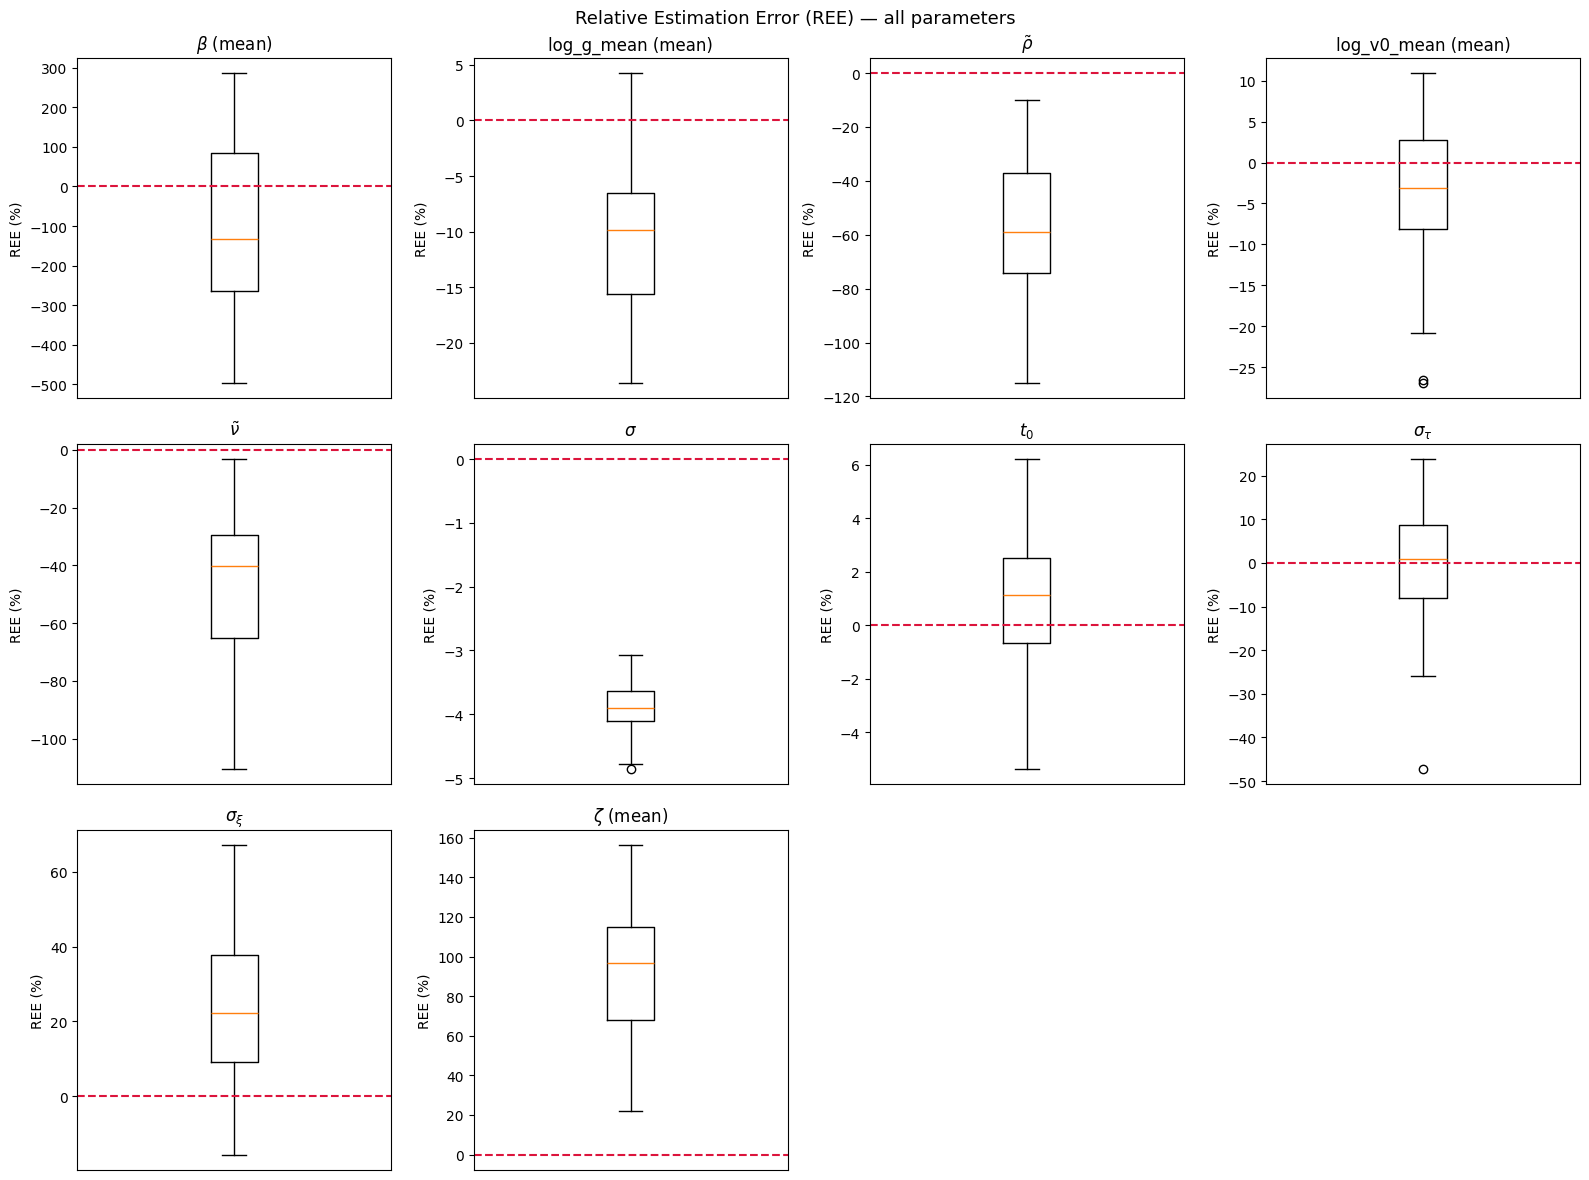

In [10]:
if ree_dict:
    n_params = len(ree_dict)
    ncols = min(4, n_params)
    nrows = (n_params + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    axes = np.array(axes).ravel()

    for ax, (label, ree_vals) in zip(axes, ree_dict.items()):
        ax.boxplot([ree_vals], vert=True)
        ax.axhline(0, color="crimson", linestyle="--", lw=1.5)
        ax.set_ylabel("REE (%)")
        ax.set_title(label)
        ax.set_xticks([])

    for ax in axes[n_params:]:
        ax.set_visible(False)

    fig.suptitle("Relative Estimation Error (REE) — all parameters", fontsize=13)
    plt.tight_layout()
    plt.show()

## Random effects: ICC 

The estimation of the random effects is assessed using the **intraclass correlation**
between the personalised values and the true values used for simulation.

We use ICC(3,1) — two-way mixed-effects model, single rater, absolute agreement:

$$ICC(3,1) = \frac{MS_B - MS_E}{MS_B + (k-1)\,MS_E}, \quad k=2$$

For reference, the Pearson correlation (which measures association but not agreement) is also reported.

           ICC(3,1)     Pearson r
-----------------------------------
xi     0.892 +/- 0.040  0.911 +/- 0.029
tau    0.910 +/- 0.069  0.922 +/- 0.056


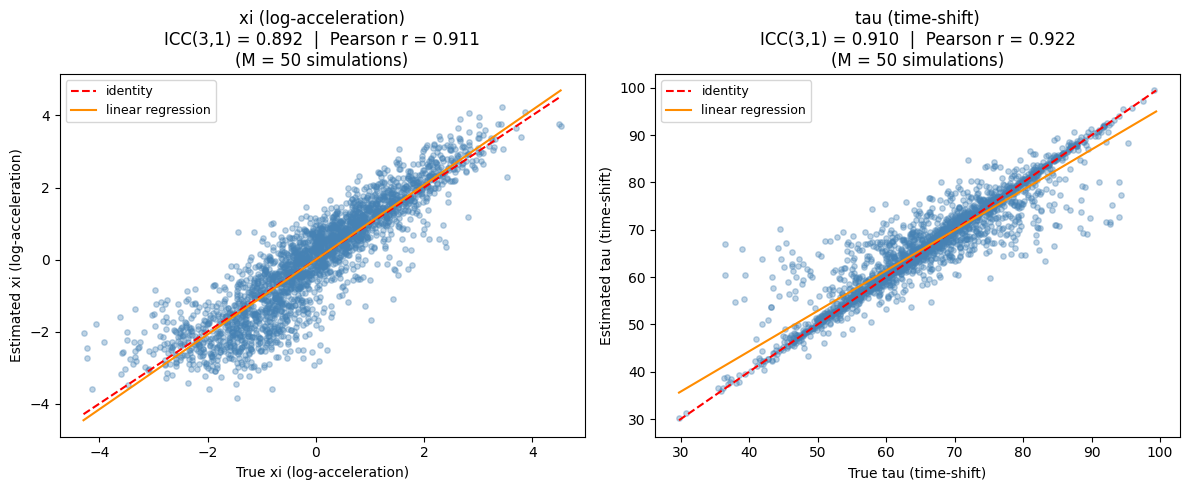

In [11]:
def icc_3_1(y_true, y_hat):
    """
    ICC(3,1) for k=2 raters (true vs estimated), absolute agreement.

    Parameters
    ----------
    y_true, y_hat : array-like of length n

    Returns
    -------
    float
    """
    y_true = np.asarray(y_true, dtype=float)
    y_hat  = np.asarray(y_hat,  dtype=float)
    n = len(y_true)
    if n < 3:
        return float("nan")
    k = 2
    y = np.stack([y_true, y_hat], axis=1)   # (n, 2)
    grand_mean = y.mean()
    row_means  = y.mean(axis=1)             # subject means
    ss_b = k * np.sum((row_means - grand_mean) ** 2)
    ss_e = np.sum((y - row_means[:, None]) ** 2)
    ms_b = ss_b / (n - 1)
    ms_e = ss_e / (n * (k - 1))
    return float((ms_b - ms_e) / (ms_b + (k - 1) * ms_e))


valid_pairs = [
    (t, e)
    for t, e in zip(results["true_ips"], results["est_ips"])
    if t is not None and e is not None
]

if not valid_pairs:
    print("No valid personalisation results — ICC cannot be computed.")
else:
    ip_cols  = ["xi", "tau"]
    ip_names = ["xi (log-acceleration)", "tau (time-shift)"]

    fig, axes = plt.subplots(1, len(ip_cols), figsize=(6 * len(ip_cols), 5))

    print(f"{'':5s}  {'ICC(3,1)':>12s}  {'Pearson r':>12s}")
    print("-" * 35)

    for ax, col, col_name in zip(axes, ip_cols, ip_names):
        icc_vals, r_vals = [], []
        all_true, all_hat = [], []

        for true_df, est_df in valid_pairs:
            # Align subjects by ID
            common = true_df.index.astype(str).intersection(est_df.index.astype(str))
            if len(common) < 3:
                continue
            yt = true_df.loc[true_df.index.astype(str).isin(common), col].to_numpy(dtype=float)
            yh = est_df.loc[est_df.index.astype(str).isin(common),  col].to_numpy(dtype=float)

            all_true.append(yt)
            all_hat.append(yh)
            icc_vals.append(icc_3_1(yt, yh))
            if np.std(yt) > 0 and np.std(yh) > 0:
                r_vals.append(pearsonr(yt, yh)[0])

        at = np.concatenate(all_true)
        ah = np.concatenate(all_hat)

        ax.scatter(at, ah, alpha=0.35, s=15, color="steelblue")
        lo, hi = min(at.min(), ah.min()), max(at.max(), ah.max())
        ax.plot([lo, hi], [lo, hi], "r--", lw=1.5, label="identity")

        slope, intercept = np.polyfit(at, ah, 1)
        ax.plot(
            [lo, hi],
            [slope * lo + intercept, slope * hi + intercept],
            color="darkorange",
            lw=1.5,
            label="linear regression",
        )

        ax.set_xlabel(f"True {col_name}")
        ax.set_ylabel(f"Estimated {col_name}")

        icc_m = np.nanmean(icc_vals)
        r_m   = np.nanmean(r_vals) if r_vals else float("nan")
        ax.set_title(
            f"{col_name}\nICC(3,1) = {icc_m:.3f}  |  Pearson r = {r_m:.3f}\n"
            f"(M = {len(valid_pairs)} simulations)"
        )
        ax.legend(fontsize=9)

        icc_s = np.nanstd(icc_vals)
        r_s   = np.nanstd(r_vals) if r_vals else float("nan")
        print(f"{col:5s}  {icc_m:.3f} +/- {icc_s:.3f}  {r_m:.3f} +/- {r_s:.3f}")

    plt.tight_layout()
    plt.show()
